In [1]:

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

print("all done")


all done


In [5]:
df = pd.read_csv("../data/retail_sales_dataset.csv")
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [6]:
df.shape
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


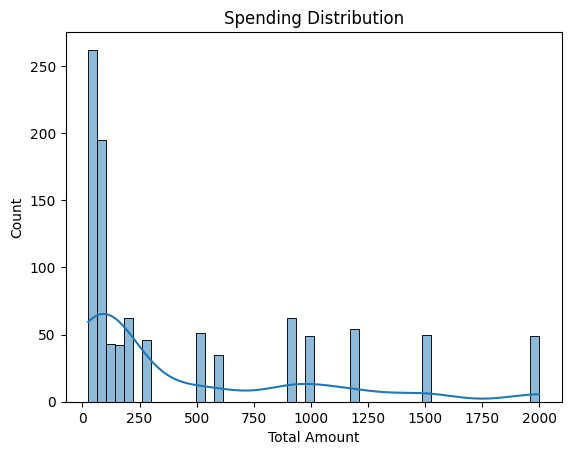

In [ ]:
import os


os.makedirs("figures", exist_ok=True)

sns.histplot(df["Total Amount"], bins=50, kde=True)

plt.title("Spending Distribution")
plt.savefig("figures/spending_distribution.png")
plt.show()


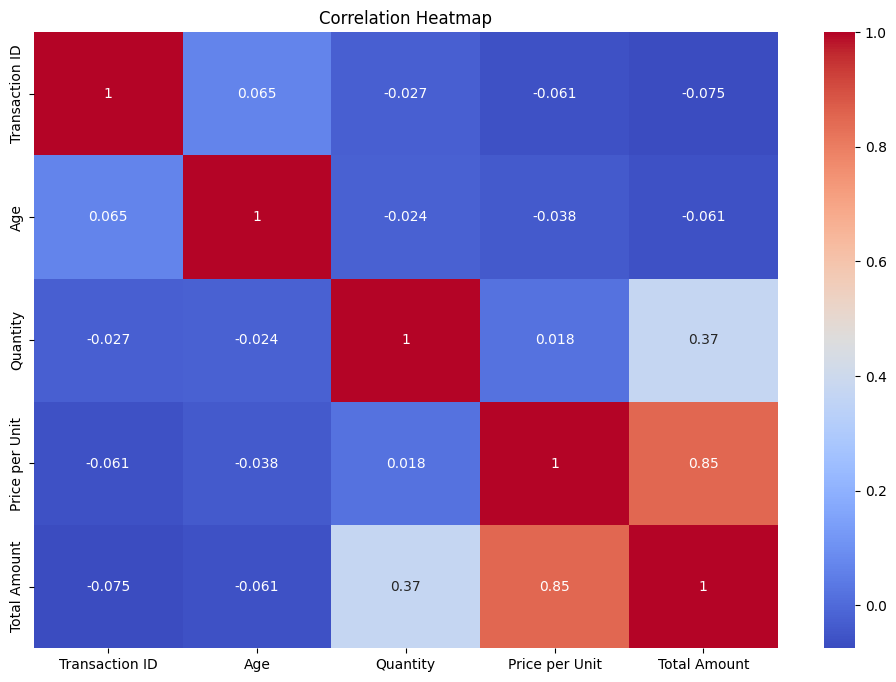

In [11]:
plt.figure(figsize=(12,8))

# Add numeric_only=True here!
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True)

plt.title("Correlation Heatmap")
plt.savefig("figures/spending_heatmap.png")
plt.show()


In [13]:
df["Total Amount"].describe()

count    1000.000000
mean      456.000000
std       559.997632
min        25.000000
25%        60.000000
50%       135.000000
75%       900.000000
max      2000.000000
Name: Total Amount, dtype: float64

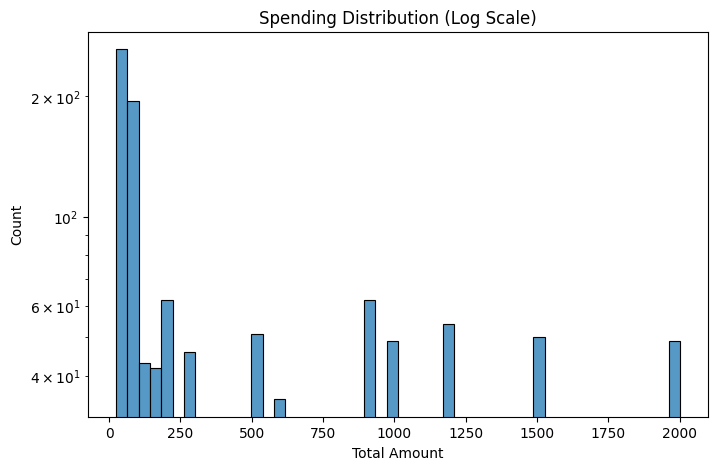

In [14]:
# ================================
# DISTRIBUTION (LOG SCALE)
# ================================
plt.figure(figsize=(8,5))
sns.histplot(df["Total Amount"], bins=50)
plt.yscale("log")
plt.title("Spending Distribution (Log Scale)")
plt.show()

In [16]:
# FEATURE VS TARGET ANALYSIS
# ================================
# Example: Transaction Amount vs Spending
if "Amount" in df.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=df["Amount"], y=df["Total Amount"])
    plt.title("Amount vs Spending")
    plt.savefig("figures/amount_vs_spending.png")
    plt.show()

In [19]:
# ================================
# TIME-BASED ANALYSIS (if exists)
# ================================
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df.set_index("Date", inplace=True)

    # Change "M" to "ME" right here!
    df["Total Amount"].resample("ME").mean().plot()
    plt.title("Monthly Average Spending")
    plt.savefig("figures/monthly_spending.png")
    plt.show()


In [ ]:
df.isnull().sum()

Transaction ID      0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64